In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
df = pd.read_csv('../data/raw/dataset.csv')
print(df.shape)
df.head()

(975, 30)


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,0.09570,0.09397,0.09187,0.09041,0.08908,0.08795,0.17840,0.17237,0.16928,NaN,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,0.09837,0.09619,0.09413,0.09236,0.09057,0.08925,0.17962,0.17477,NaN,0.16534,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,0.08996,0.08861,0.08697,0.08627,0.08541,NaN,0.18010,0.17574,0.17154,0.16567,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN
3,07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,0.09864,0.09511,0.09304,0.09123,NaN,0.08843,0.18174,NaN,0.17206,0.16502,0.15755,NaN,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200
4,07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,0.09896,NaN,0.09412,0.09136,0.09014,0.08885,0.18193,NaN,0.17226,0.16522,0.15924,0.15334,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN


In [5]:
df['datetime'] = pd.to_datetime(df['datetime'],dayfirst=True)

option_cols = [c for c in df.columns if c not in ['datetime','underlying_price']]
ce_cols = [c for c in option_cols if c.endswith('CE')]
pe_cols = [c for c in option_cols if c.endswith('PE')]

### 1. Transforming dataset to long format

In [6]:
# for CE options

df_ce = df.melt(
    id_vars=['datetime','underlying_price'],
    value_vars=ce_cols,
    var_name='contract',
    value_name='iv'
)

df_ce['option_type'] = 'CE'

df_ce['strike'] = df_ce['contract'].str[12:-2].astype(int)

df_pe = df.melt(
    id_vars = ['datetime','underlying_price'],
    value_vars=pe_cols,
    var_name='contract',
    value_name='iv'
)

df_pe['option_type'] = 'PE'

df_pe['strike'] = df_pe['contract'].str[12:-2].astype(int)

df_long = pd.concat([df_ce,df_pe],ignore_index=True)

df_long = (
    df_long.sort_values(['datetime','option_type','strike']).reset_index(drop=True)
)

print(df_long.shape)
print(df_long['iv'].isna().sum())
df_long.head(5)

(27300, 6)
5460


,datetime,underlying_price,contract,iv,option_type,strike
0,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625200CE,0.12662,CE,25200
1,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625300CE,0.12330,CE,25300
2,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625400CE,0.11741,CE,25400
3,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625500CE,NaN,CE,25500
4,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625600CE,0.11005,CE,25600


### 2. Creating time features

In [9]:
df_long['hour'] = df_long['datetime'].dt.hour
df_long['minute'] = df_long['datetime'].dt.minute
df_long['day_of_week'] = df_long['datetime'].dt.dayofweek
df_long['date'] = df_long['datetime'].dt.date

session_start_min = df_long.iloc[0]['hour']*60 + df_long.iloc[0]['minute']
session_end_min = df_long.iloc[-1]['hour']*60 + df_long.iloc[-1]['minute']

df_long['session_progress'] = ((df_long['hour']*60 + df_long['minute'] - session_start_min)/(session_end_min - session_start_min)).clip(0,1)

df_long['days_to_expiry'] = ((df_long.iloc[-1]['datetime'] - df_long['datetime']).dt.total_seconds()/(60*60*24)).clip(lower=0).round(4)

print(df_long.shape)
df_long.sample(5)

(27300, 12)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry
26197,2026-01-27 12:10:00,25117.85,NIFTY27JAN2624100PE,0.79545,PE,24100,12,10,1,2026-01-27,0.472973,0.1354
11486,2026-01-14 12:10:00,25757.05,NIFTY27JAN2625800CE,0.09262,CE,25800,12,10,2,2026-01-14,0.472973,13.1354
15444,2026-01-19 11:25:00,25514.95,NIFTY27JAN2624000PE,0.19201,PE,24000,11,25,0,2026-01-19,0.351351,8.1667
14375,2026-01-16 14:30:00,25688.20,NIFTY27JAN2626300CE,NaN,CE,26300,14,30,4,2026-01-16,0.851351,11.0382
421,2026-01-07 10:30:00,26130.45,NIFTY27JAN2625300CE,0.13392,CE,25300,10,30,2,2026-01-07,0.202703,20.2049


### 3. Creating moneyness, dist. from atm, flag ce features

In [10]:
df_long['moneyness'] = df_long['strike']/df_long['underlying_price']
df_long['log_moneyness'] = np.log(df_long['moneyness'])

df_long['dist_from_atm'] = np.abs(df_long['strike']-df_long['underlying_price'])
df_long['dist_from_atm_pct'] = df_long['dist_from_atm']/df_long['underlying_price']

df_long['is_ce'] = (df_long['option_type'] == 'CE').astype(int)

print(df_long.shape)
df_long.sample(5)

(27300, 17)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce
2434,2026-01-08 10:10:00,26050.30,NIFTY27JAN2625000PE,NaN,PE,25000,10,10,3,2026-01-08,0.148649,19.2188,0.959682,-0.041153,1050.30,0.040318,0
10516,2026-01-14 09:15:00,25671.90,NIFTY27JAN2624000PE,0.18191,PE,24000,9,15,2,2026-01-14,0.000000,13.2569,0.934874,-0.067343,1671.90,0.065126,0
2295,2026-01-08 09:45:00,26077.70,NIFTY27JAN2625100PE,0.10919,PE,25100,9,45,3,2026-01-08,0.081081,19.2361,0.962508,-0.038213,977.70,0.037492,0
9448,2026-01-13 12:20:00,25724.70,NIFTY27JAN2626400CE,0.10438,CE,26400,12,20,1,2026-01-13,0.500000,14.1285,1.026251,0.025912,675.30,0.026251,1
17206,2026-01-20 10:25:00,25487.25,NIFTY27JAN2623800PE,NaN,PE,23800,10,25,1,2026-01-20,0.189189,7.2083,0.933800,-0.068493,1687.25,0.066200,0


### 4. Creating strike rank feature: unlike moneyness it is static feature which can help in edge detection

In [11]:
for otype in ['CE','PE']:
    mask = (df_long['option_type'] == otype)
    strikes_sorted = sorted(df_long.loc[mask,'strike'].unique())
    rank_map = {s:i/(len(strikes_sorted)-1) for i,s in enumerate(strikes_sorted)}
    df_long.loc[mask,'strike_rank'] = df_long.loc[mask,'strike'].map(rank_map)

print(df_long.shape)
df_long.sample(5)

(27300, 18)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce,strike_rank
5254,2026-01-09 12:20:00,25738.70,NIFTY27JAN2624200PE,0.15058,PE,24200,12,20,4,2026-01-09,0.500000,18.1285,0.940218,-0.061643,1538.70,0.059782,0,0.307692
21633,2026-01-22 11:05:00,25223.35,NIFTY27JAN2624100PE,0.20118,PE,24100,11,5,3,2026-01-22,0.297297,5.1806,0.955464,-0.045558,1123.35,0.044536,0,0.230769
15604,2026-01-19 11:55:00,25540.75,NIFTY27JAN2626000CE,0.10829,CE,26000,11,55,0,2026-01-19,0.432432,8.1458,1.017981,0.017821,459.25,0.017981,1,0.615385
4352,2026-01-09 09:40:00,25822.35,NIFTY27JAN2626400CE,0.09868,CE,26400,9,40,4,2026-01-09,0.067568,18.2396,1.022370,0.022124,577.65,0.022370,1,0.923077
7703,2026-01-12 13:25:00,25704.15,NIFTY27JAN2625500CE,NaN,CE,25500,13,25,0,2026-01-12,0.675676,15.0833,0.992058,-0.007974,204.15,0.007942,1,0.230769


### 5. Creating neighbour IV feature: curve for IV at same timestamp and varying strikes shows smooth behaviour suggesting strong predicting capability of neighboring strikes

In [13]:
df_long = df_long.sort_values(['datetime','option_type','strike']).reset_index(drop=True)

for shift_val in [-2,-1,1,2]:
    col = f"iv_neighbor_{shift_val:+d}"
    df_long[col] = df_long.groupby(['datetime','option_type'])['iv'].shift(-shift_val)

df_long['iv_neighbor_mean'] = df_long[['iv_neighbor_+1','iv_neighbor_-1']].mean(axis=1)
df_long['wide_iv_neighbor_mean'] = df_long[['iv_neighbor_+2','iv_neighbor_-2']].mean(axis=1)

print(df_long.shape)
df_long.sample(5)

(27300, 24)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce,strike_rank,iv_neighbor_-2,iv_neighbor_-1,iv_neighbor_+1,iv_neighbor_+2,iv_neighbor_mean,wide_iv_neighbor_mean
7091,2026-01-12 11:35:00,25487.10,NIFTY27JAN2625900CE,0.11034,CE,25900,11,35,0,2026-01-12,0.378378,15.1597,1.016200,0.016071,412.90,0.016200,1,0.538462,0.11321,NaN,0.11030,0.11119,0.110300,0.112200
15075,2026-01-19 10:20:00,25543.90,NIFTY27JAN2626300CE,NaN,CE,26300,10,20,0,2026-01-19,0.175676,8.2118,1.029600,0.029170,756.10,0.029600,1,0.846154,0.11390,0.11814,0.12856,0.13525,0.123350,0.124575
19060,2026-01-21 09:40:00,25195.85,NIFTY27JAN2624400PE,NaN,PE,24400,9,40,2,2026-01-21,0.067568,6.2396,0.968413,-0.032096,795.85,0.031587,0,0.461538,0.18912,0.17868,0.15788,0.14814,0.168280,0.168630
22628,2026-01-22 14:05:00,25228.35,NIFTY27JAN2625600CE,0.11323,CE,25600,14,5,3,2026-01-22,0.783784,5.0556,1.014731,0.014624,371.65,0.014731,1,0.307692,0.10712,0.10975,0.11804,0.12407,0.113895,0.115595
8846,2026-01-13 10:30:00,25804.60,NIFTY27JAN2625000PE,0.12664,PE,25000,10,30,1,2026-01-13,0.202703,14.2049,0.968820,-0.031677,804.60,0.031180,0,0.923077,0.13714,NaN,0.12147,NaN,0.121470,0.137140


### 6. Lag and rolling feature: curve for a particular strike's IV vs time is also smooth for a trading day suggesting high dependency of a particular IV on previous IVs


In [14]:
df_long = df_long.sort_values(['option_type','strike','datetime']).reset_index(drop=True)

df_long['iv_lag_1'] = df_long.groupby(['option_type','strike'])['iv'].shift(1)

df_long['iv_roll_mean_5'] = df_long.groupby(['option_type','strike'])['iv'].transform(
    lambda x: x.shift(1).rolling(5,min_periods=2).mean()
)

df_long['iv_roll_std_5'] = df_long.groupby(['option_type','strike'])['iv'].transform(
    lambda x: x.shift(1).rolling(5,min_periods=2).std()
)

df_long['iv_roll_mean_10'] = df_long.groupby(['option_type','strike'])['iv'].transform(
    lambda x: x.shift(1).rolling(10,min_periods=3).mean()
)

print(df_long.shape)
df_long.sample(5)

(27300, 28)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce,strike_rank,iv_neighbor_-2,iv_neighbor_-1,iv_neighbor_+1,iv_neighbor_+2,iv_neighbor_mean,wide_iv_neighbor_mean,iv_lag_1,iv_roll_mean_5,iv_roll_std_5,iv_roll_mean_10
11038,2026-01-13 10:20:00,25761.35,NIFTY27JAN2626300CE,0.10477,CE,26300,10,20,1,2026-01-13,0.175676,14.2118,1.020909,0.020694,538.65,0.020909,1,0.846154,0.10338,0.10386,0.10632,NaN,0.105090,0.103380,0.10428,0.105552,0.002141,0.105069
17500,2026-01-27 11:20:00,25044.90,NIFTY27JAN2624100PE,0.68763,PE,24100,11,20,1,2026-01-27,0.337838,0.1701,0.962272,-0.038458,944.90,0.037728,0,0.230769,0.80380,0.75361,0.63226,0.56455,0.692935,0.684175,0.67934,0.656627,0.020671,0.663230
2375,2026-01-14 13:25:00,25715.50,NIFTY27JAN2625400CE,0.09996,CE,25400,13,25,2,2026-01-14,0.675676,13.0833,0.987731,-0.012345,315.50,0.012269,1,0.153846,NaN,0.10317,0.09726,NaN,0.100215,NaN,0.09116,0.095295,0.005025,0.097026
1827,2026-01-23 11:30:00,25274.70,NIFTY27JAN2625300CE,0.08955,CE,25300,11,30,4,2026-01-23,0.364865,4.1632,1.001001,0.001001,25.30,0.001001,1,0.076923,NaN,0.09177,0.08944,NaN,0.090605,NaN,0.10164,0.103470,0.001845,0.101610
6099,2026-01-12 11:15:00,25528.80,NIFTY27JAN2625800CE,NaN,CE,25800,11,15,0,2026-01-12,0.324324,15.1736,1.010623,0.010567,271.20,0.010623,1,0.461538,0.11333,NaN,0.10818,0.10776,0.108180,0.110545,NaN,0.109390,0.002384,0.110166


### 7. Cross-area feature creation

In [16]:
mean_ce_iv = (
    df_long[df_long['option_type'] == 'CE'].groupby('datetime')['iv'].mean()
)

mean_pe_iv = (
    df_long[df_long['option_type'] == 'PE'].groupby('datetime')['iv'].mean()
)

df_long['mean_ce_iv'] = df_long['datetime'].map(mean_ce_iv)
df_long['mean_pe_iv'] = df_long['datetime'].map(mean_pe_iv)

print(df_long.shape)
df_long.sample(5)

(27300, 30)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce,strike_rank,iv_neighbor_-2,iv_neighbor_-1,iv_neighbor_+1,iv_neighbor_+2,iv_neighbor_mean,wide_iv_neighbor_mean,iv_lag_1,iv_roll_mean_5,iv_roll_std_5,iv_roll_mean_10,mean_ce_iv,mean_pe_iv
24998,2026-01-20 11:10:00,25452.35,NIFTY27JAN2624900PE,NaN,PE,24900,11,10,1,2026-01-20,0.310811,7.1771,0.978299,-0.021940,552.35,0.021701,0,0.846154,0.13592,0.13029,0.12090,0.11660,0.125595,0.126260,0.12559,0.126400,0.000798,0.126670,0.117889,0.161941
23681,2026-01-12 13:55:00,25743.25,NIFTY27JAN2624800PE,0.13473,PE,24800,13,55,0,2026-01-12,0.756757,15.0625,0.963359,-0.037329,943.25,0.036641,0,0.769231,0.14559,NaN,NaN,0.12508,NaN,0.135335,0.13388,0.134097,0.000455,0.133644,0.116528,0.151151
4322,2026-01-14 13:10:00,25759.75,NIFTY27JAN2625600CE,0.09087,CE,25600,13,10,2,2026-01-14,0.635135,13.0938,0.993798,-0.006221,159.75,0.006202,1,0.307692,0.09268,0.09214,0.09034,NaN,0.091240,0.092680,0.10022,0.097945,0.001680,0.097344,0.093446,0.156381
11109,2026-01-14 10:00:00,25727.85,NIFTY27JAN2626300CE,0.09918,CE,26300,10,0,2,2026-01-14,0.121622,13.2257,1.022239,0.021995,572.15,0.022239,1,0.846154,NaN,0.09783,0.10196,NaN,0.099895,NaN,0.09740,0.101038,0.003279,0.101171,0.103841,0.153915
9875,2026-01-08 13:25:00,25911.75,NIFTY27JAN2626200CE,0.09439,CE,26200,13,25,3,2026-01-08,0.675676,19.0833,1.011124,0.011063,288.25,0.011124,1,0.769231,NaN,NaN,0.09305,0.09214,0.093050,0.092140,NaN,0.098020,0.003154,0.097748,0.104102,0.151960


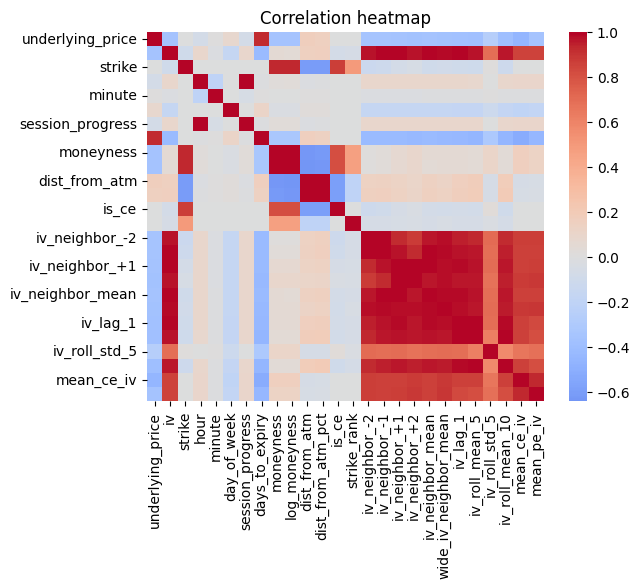

In [17]:
corr_matrix = df_long.corr(numeric_only=True)

sns.heatmap(corr_matrix,annot=False,cmap='coolwarm',center=0)

plt.title('Correlation heatmap')
plt.show()

In [21]:
corr_matrix['iv'].sort_values(ascending=True)

days_to_expiry          -0.424111
underlying_price        -0.358997
day_of_week             -0.168710
strike                  -0.090224
is_ce                   -0.073326
strike_rank             -0.053339
minute                  -0.014004
log_moneyness            0.043982
moneyness                0.047398
session_progress         0.085931
hour                     0.086473
dist_from_atm            0.149811
dist_from_atm_pct        0.158568
iv_roll_std_5            0.688010
mean_ce_iv               0.852225
mean_pe_iv               0.852838
iv_roll_mean_10          0.963097
iv_neighbor_+2           0.968138
iv_neighbor_-2           0.968138
iv_roll_mean_5           0.973816
wide_iv_neighbor_mean    0.986482
iv_lag_1                 0.988060
iv_neighbor_+1           0.991936
iv_neighbor_-1           0.991936
iv_neighbor_mean         0.996819
iv                       1.000000
Name: iv, dtype: float64

In [22]:
df_long.to_csv('../data/processed/dataset_long.csv',index=False)